# AI Clustering

> Concepts and demos

### What is Clustering?
Clustering is an **Unsupervised Machine Learning** technique. Unlike supervised learning (such as classification), we don't have labeled data (no "correct answers"). The algorithm's job is to discover hidden patterns and group similar data points together.

### Real-world Applications
* **Customer Segmentation:** Grouping buyers with similar purchasing habits. 🎯 
* **Anomaly Detection:** Finding outliers (e.g., credit card fraud). 🚨 
* **Biology:** Grouping genes with similar expression patterns. 🧬 

### How K-Means Works
1. Pick $K$ random points as the initial "centers" (centroids) of our clusters.
2. Assign every data point to its closest centroid. But how do we measure "closest"? We have different ways:

| Euclidean Distance | Cosine Distance |
| :--- | :--- |
| Euclidean Distance is just the **Pythagorean Theorem** ($a^2 + b^2 = c^2$) applied to coordinates! To find the straight-line distance ($d$) between a data point $(x_1, y_1)$ and a centroid $(x_2, y_2)$, the algorithm calculates:<br><br>$$ d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} $$<br><br><center><img src="https://mathcracker.com/images/legacy/distance-formula-1.jpg" width="250" alt="Euclidean Distance"></center> | Instead of measuring the physical distance between two points, **Cosine Distance** measures the *angle* ($\theta$) between them when drawn as lines (vectors) from the origin (0,0).<br><br>It ignores how "far" the point is and focuses purely on its **direction**. This is exactly how we compare text embeddings!<br><br>$$ \text{Cosine Distance} = 1 - \frac{A \cdot B}{\|A\| \|B\|} = 1 - \cos(\theta) $$<br><br><center><img src="cosine-similarity.png" width="250" alt="Cosine Similarity"></center> |

3. Recalculate the center of each cluster based on the points assigned to it.
4. Repeat steps 2 and 3 until the centroids stop moving!

<br>
<center>
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif" width="500" alt="K-Means Clustering Animation">
  <br>
  <i>Watch the K-Means algorithm in action! (Initial placement -> Assignment -> Update)</i>
</center>

### K-Means from Scratch!

Implementing k-means with pure math and python code

In [75]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

sns.set_theme(style="darkgrid")

In [76]:
def euclidean_distance(point1, point2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(point1, point2)))

def kmeans_scratch(data, k, max_iters=100, random_state=None):
    # Convert points to tuples for clean Python processing
    data_list = [tuple(p) for p in data]
    
    if random_state is not None:
        random.seed(random_state)
        
    centroids = random.sample(data_list, k)
    labels = []
    
    for iteration in range(max_iters):
        clusters = [[] for _ in range(k)]
        new_labels = []
        
        # Assign points to closest centroid
        for point in data_list:
            distances = [euclidean_distance(point, centroid) for centroid in centroids]
            closest_idx = distances.index(min(distances))
            new_labels.append(closest_idx)
            clusters[closest_idx].append(point)
        
        # Recalculate centroids
        new_centroids = []
        for cluster in clusters:
            if not cluster:
                continue

            """
            * cluster = [(1.0, 2.0), (3.0, 4.0), (5.0, 6.0)]
            * zip(*cluster)
                * x-coordinates: (1.0, 3.0, 5.0)
                * y-coordinates: (2.0, 4.0, 6.0)
            * 1st iteration: sum((1.0, 3.0, 5.0)) / 3 = 3.0
            * 2nd iteration: sum((2.0, 4.0, 6.0)) / 3 = 4.0
            * dimension_means = (3.0, 4.0)
            """
            dimension_means = tuple(sum(dimension) / len(cluster) for dimension in zip(*cluster))
            new_centroids.append(dimension_means)
            
        labels = new_labels
        
        if np.allclose(new_centroids, centroids):
            print(f"Convergence reached at iteration {iteration + 1}!")
            break
            
        centroids = new_centroids
        
    return np.array(centroids), np.array(labels)

Convergence reached at iteration 3!

Final Centroids Found:
Centroid 1: (1.26, 1.20)
Centroid 2: (8.75, 8.75)
Centroid 3: (8.50, 1.10)
Centroid 4: (1.38, 8.67)

Cluster Assignments:
Cluster 0: 5 points
   - (1.0, 1.0)
   - (1.2, 0.5)
   - (1.5, 1.2)
   - (0.8, 1.8)
   - (1.8, 1.5)
Cluster 1: 4 points
   - (8.5, 9.5)
   - (9.0, 9.0)
   - (9.5, 8.5)
   - (8.0, 8.0)
Cluster 2: 3 points
   - (8.0, 1.0)
   - (8.5, 0.8)
   - (9.0, 1.5)
Cluster 3: 6 points
   - (1.5, 9.0)
   - (1.8, 8.8)
   - (0.8, 8.5)
   - (2.0, 8.2)
   - (1.0, 8.0)
   - (1.2, 9.5)


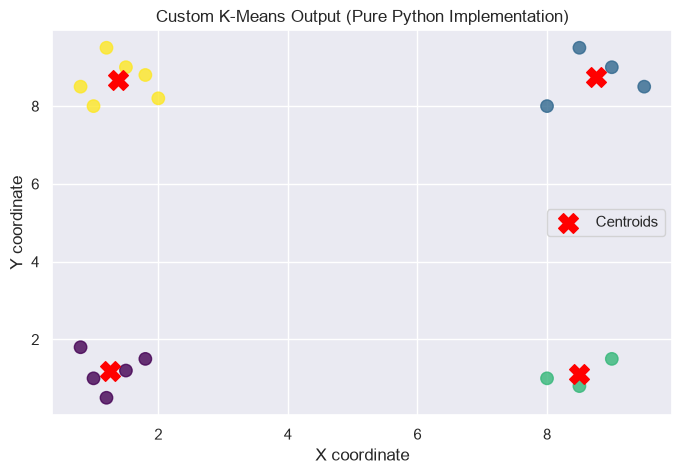

In [77]:
custom_points = np.array([
    (8.5, 9.5), (1.0, 1.0), (1.5, 9.0), (8.0, 1.0),
    (1.8, 8.8), (1.2, 0.5), (9.0, 9.0), (0.8, 8.5),
    (8.5, 0.8), (1.5, 1.2), (2.0, 8.2), (9.5, 8.5),
    (0.8, 1.8), (1.0, 8.0), (9.0, 1.5), (1.2, 9.5),
    (1.8, 1.5), (8.0, 8.0)
])

centroids, predicted_clusters = kmeans_scratch(custom_points, k=4, random_state=42)

print("\nFinal Centroids Found:")
for i, c in enumerate(centroids):
    print(f"Centroid {i+1}: ({c[0]:.2f}, {c[1]:.2f})")

print("\nCluster Assignments:")
for cluster_id in range(len(centroids)): 
    assigned_points = custom_points[predicted_clusters == cluster_id]
    print(f"Cluster {cluster_id}: {len(assigned_points)} points")
    for pt in assigned_points:
        print(f"   - {tuple(pt.tolist())}")

plt.figure(figsize=(8, 5))
plt.scatter(custom_points[:, 0], custom_points[:, 1], c=predicted_clusters, s=80, cmap='viridis', alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("Custom K-Means Output (Pure Python Implementation)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.show()

Raw Data coordinates (First 5 points):
x: -9.99, y: 5.20
x: -10.99, y: 6.36
x: -0.45, y: 5.96
x: -7.42, y: -4.13
x: -13.93, y: 4.80



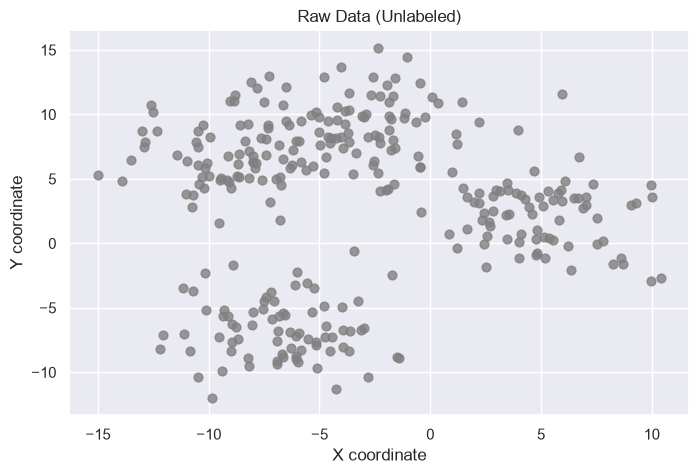

In [78]:
# Generating synthetic 2D data example
# Create 300 points distributed around 4 centers, 
# with 2.50 as cluster standard deviation (dispersed and heavily overlapping clusters)
points, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=2.50, random_state=42)

print("Raw Data coordinates (First 5 points):")
for p in points[:5]:
    print(f"x: {p[0]:.2f}, y: {p[1]:.2f}")
print()

# raw data (as the algorithm sees it: no colors, no labels)
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1], s=40, color='gray', alpha=0.8)
plt.title("Raw Data (Unlabeled)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.show()

### Usage of K-Means!
Now, let's use the k-means algorithm to find these 4 clusters automatically.

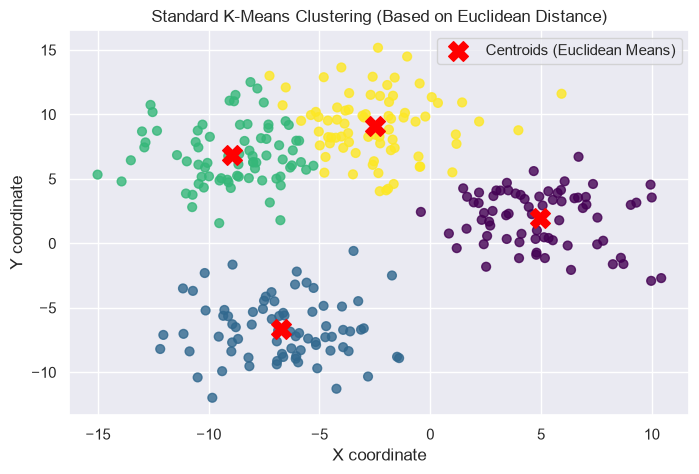

In [79]:
# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(points)

# Get the predicted clusters and the centroids
predicted_clusters = kmeans.predict(points)
centroids = kmeans.cluster_centers_

# Visualize the result
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1], c=predicted_clusters, s=40, cmap='viridis', alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids (Euclidean Means)')
plt.title("Standard K-Means Clustering (Based on Euclidean Distance)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend()
plt.show()

---
## Clustering on Modern AI

If clustering groups points based on math and distance, how can we group **texts**, **images**, or **concepts**? Algorithms don't understand words; they only understand numbers.

### Enter: Embeddings
An **Embedding** is a translation powered by Neural Networks that converts unstructured data—like text, images, or real-world concepts—into dense vectors (lists of numbers) in a high-dimensional space.

* **Semantic Proximity:** Concepts with similar meanings end up **closer together** in the vector space (e.g., *"king"* and *"queen"*, or *"dog"* and *"cat"*).
* **Distance Metrics:** Algorithms use mathematical measures like **Cosine Similarity** or **Euclidean Distance** to calculate these distances and cluster similar concepts together.

![embeddings](embeddings.png)

In [ ]:
# Load a lightweight, pre-trained AI model to generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

# Dataset of sentences from 4 different topics (Food, Sports, Tech, Travel)
sentences = [
    "A good pasta recipe needs fresh tomatoes and basil.",                     # Food
    "The soccer player scored a beautiful goal in the championship match.",    # Sports
    "A scenic train ride through the Swiss Alps offers breathtaking views.",   # Travel
    "Python is a great programming language for data analysis.",               # Tech
    "Tennis players need excellent hand-eye coordination.",                    # Sports
    "Baking chocolate chip cookies makes the house smell great.",              # Food
    "Machine learning algorithms are evolving fast every year.",               # Tech
    "The Olympics showcase the best athletes from around the world.",          # Sports
    "Sushi is a traditional Japanese dish with rice and raw fish.",            # Food
    "Backpacking through Southeast Asia is a budget-friendly adventure.",      # Travel
    "Software engineers write code to build web applications.",                # Tech
    "Basketball requires a lot of stamina, vertical jump, and teamwork.",      # Sports
    "I love eating pepperoni pizza with extra cheese on weekends.",            # Food
    "Cloud computing allows companies to scale their servers dynamically.",    # Tech
    "Booking flights early can save a lot of money on international trips.",   # Travel
    "A heavy deadlift builds incredible strength in the lower back.",          # Sports
    "Deep learning models require powerful GPUs to train efficiently.",        # Tech
    "Grilling a perfect steak requires high heat and a little bit of butter.", # Food
    "Staying at a local hostel is a great way to meet fellow travelers."       # Travel
]

# Translate sentences into 384-dimensional embeddings
embeddings = model.encode(sentences, device='cpu')

# STEP FOR COSINE DISTANCE: Normalize vectors to unit length (L2 norm)
# When vectors have length = 1, Euclidean distance mathematically equals Cosine distance!
embeddings_cosine = normalize(embeddings, norm='l2')

print(f"Number of sentences: {len(sentences)}")
print(f"Vector dimensions: {embeddings.shape[1]}")
print("Embeddings successfully normalized for Cosine Distance (Spherical K-Means)!\n")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2778.06it/s]


Number of sentences: 19
Vector dimensions: 384
Embeddings successfully normalized for Cosine Distance (Spherical K-Means)!



### Semantic Clustering
Now we have 384-dimensional vectors! We can use K-Means algorithm to group these sentences by their *meaning*.

In [81]:
# Apply K-Means to our 384-dimensional text embeddings
kmeans_nlp = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_nlp.fit(embeddings_cosine)

# Print the results grouped by their cluster
clusters = {0: [], 1: [], 2: [], 3: []}
for sentence, cluster_id in zip(sentences, kmeans_nlp.labels_):
    clusters[cluster_id].append(sentence)

print("Semantic Grouping Results:\n")
for cluster_id, cluster_sentences in clusters.items():
    print(f"Cluster {cluster_id}:")
    for s in cluster_sentences:
        print(f" - {s}")
    print()

Semantic Grouping Results:

Cluster 0:
 - A good pasta recipe needs fresh tomatoes and basil.
 - Baking chocolate chip cookies makes the house smell great.
 - Sushi is a traditional Japanese dish with rice and raw fish.
 - I love eating pepperoni pizza with extra cheese on weekends.
 - Grilling a perfect steak requires high heat and a little bit of butter.

Cluster 1:
 - The soccer player scored a beautiful goal in the championship match.
 - Tennis players need excellent hand-eye coordination.
 - The Olympics showcase the best athletes from around the world.
 - Basketball requires a lot of stamina, vertical jump, and teamwork.
 - A heavy deadlift builds incredible strength in the lower back.

Cluster 2:
 - Python is a great programming language for data analysis.
 - Machine learning algorithms are evolving fast every year.
 - Software engineers write code to build web applications.
 - Cloud computing allows companies to scale their servers dynamically.
 - Deep learning models require p

### Visualizing High Dimensions (PCA)
We humans can only see in 2D or 3D, but our embeddings live in a 384-dimensional space. To visualize our semantic clusters, we use a technique called **PCA (Principal Component Analysis)** to squash the 384 dimensions down to just 2, preserving as much information as possible.

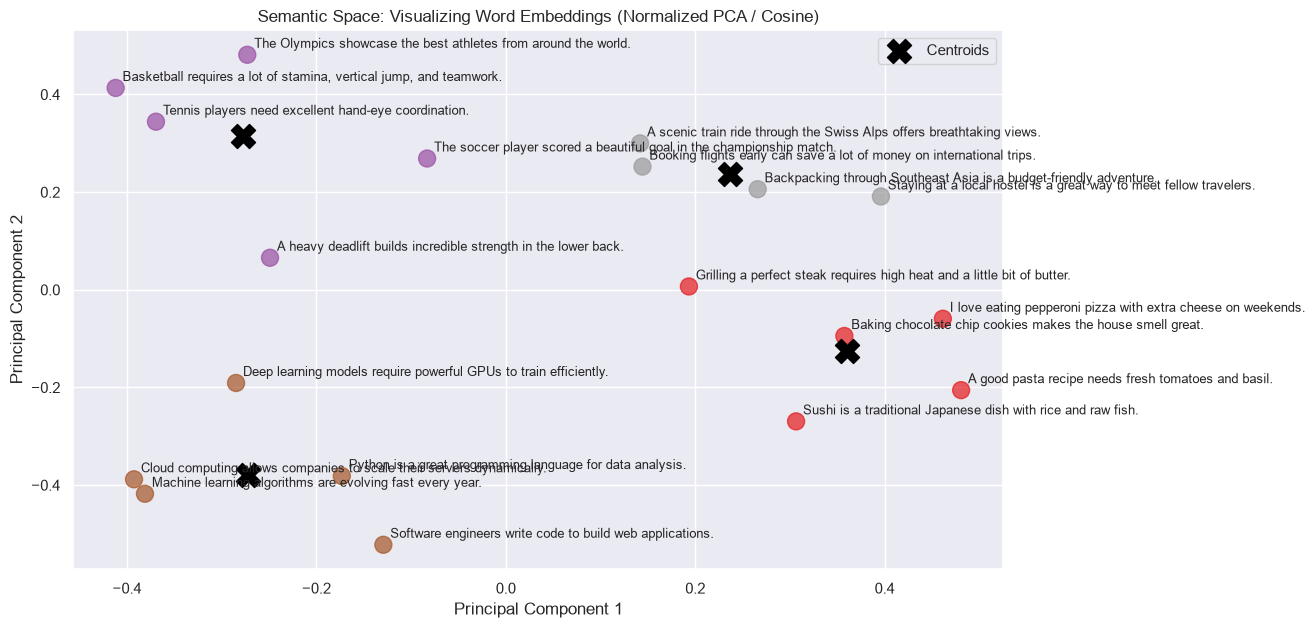

In [82]:
# Reduce 384 dimensions down to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings_cosine)

# Transform the 384-dimensional centroids into 2D using the same PCA
reduced_centroids = pca.transform(kmeans_nlp.cluster_centers_)

# Plot the semantic clusters
plt.figure(figsize=(12, 7))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                      c=kmeans_nlp.labels_, cmap='Set1', s=150, alpha=0.7)

# Plot the centroids on top
plt.scatter(reduced_centroids[:, 0], reduced_centroids[:, 1], 
            c='black', s=300, marker='X', label='Centroids')

# Add the actual sentences as labels to the points
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, 
                 (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title("Semantic Space: Visualizing Word Embeddings (Normalized PCA / Cosine)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

### The Big Picture: Vector Databases
Why does this matter today?

When you ask ChatGPT a question over your company's documents, or when Spotify recommends a song, they are using **Vector Databases** (like Pinecone, Milvus, or ChromaDB). 

These databases don't search by keywords. They convert your search into an **Embedding**, and then use clustering techniques to find the "cluster" of documents that are mathematically closest to your question.